# DNA Classification — Notebook Training Fixed

Notebook ini adalah versi perbaikan **self-contained** dari notebook lama agar dapat digunakan untuk:

1. Klasifikasi sequence DNA berdasarkan kelas: **Bacteria, Human, Plant, Virus**.
2. Estimasi tingkat keparahan/risiko: **Low, Medium, High**.
3. Penyimpanan model ke file `.joblib`.
4. Integrasi ke aplikasi **Streamlit online**.

> Catatan: hasil `Disease_Risk` adalah prediksi berbasis dataset dan bukan diagnosis medis final.

In [1]:
import json
import math
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# ============================================================
# Helper ekstraksi fitur dibuat langsung di notebook.
# Jadi notebook ini bisa berjalan di Kaggle/Jupyter tanpa file
# tambahan feature_extraction.py.
# ============================================================
VALID_BASES = {'A', 'T', 'C', 'G'}
FEATURE_COLUMNS = [
    'GC_Content',
    'AT_Content',
    'Sequence_Length',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq',
    'Mutation_Flag',
    'GC_to_AT_Ratio',
    'Sequence_Entropy',
]


def clean_sequence(sequence):
    """Membersihkan sequence: huruf besar dan menghapus spasi/baris baru."""
    if sequence is None:
        return ''
    return ''.join(str(sequence).upper().split())


def validate_sequence(sequence):
    """Validasi sequence DNA agar hanya berisi A, T, C, G."""
    seq = clean_sequence(sequence)
    if not seq:
        return False, 'Sequence masih kosong.'
    invalid = sorted(set(seq) - VALID_BASES)
    if invalid:
        return False, f"Karakter tidak valid: {', '.join(invalid)}. Gunakan hanya A, T, C, dan G."
    if len(seq) < 3:
        return False, 'Sequence minimal 3 karakter agar fitur 3-mer dapat dihitung.'
    return True, 'OK'


def sequence_entropy(sequence):
    """Menghitung Shannon entropy komposisi basa DNA."""
    seq = clean_sequence(sequence)
    total = len(seq)
    if total == 0:
        return 0.0
    counts = Counter(seq)
    entropy = 0.0
    for base in VALID_BASES:
        count = counts.get(base, 0)
        if count > 0:
            p = count / total
            entropy -= p * math.log2(p)
    return entropy


def kmer_3_unique_frequency(sequence):
    """Rasio 3-mer unik terhadap jumlah window 3-mer."""
    seq = clean_sequence(sequence)
    total = max(len(seq) - 3 + 1, 0)
    if total == 0:
        return 0.0
    kmers = {seq[i:i + 3] for i in range(total)}
    return len(kmers) / total


def extract_features_from_sequence(sequence, mutation_flag=0):
    """Mengubah satu sequence DNA menjadi fitur numerik."""
    seq = clean_sequence(sequence)
    length = len(seq)
    counts = Counter(seq)
    num_a = counts.get('A', 0)
    num_t = counts.get('T', 0)
    num_c = counts.get('C', 0)
    num_g = counts.get('G', 0)
    gc = num_g + num_c
    at = num_a + num_t

    return {
        'GC_Content': round((gc / length * 100), 6) if length else 0.0,
        'AT_Content': round((at / length * 100), 6) if length else 0.0,
        'Sequence_Length': float(length),
        'Num_A': float(num_a),
        'Num_T': float(num_t),
        'Num_C': float(num_c),
        'Num_G': float(num_g),
        'kmer_3_freq': round(kmer_3_unique_frequency(seq), 6),
        'Mutation_Flag': int(mutation_flag),
        'GC_to_AT_Ratio': round((gc / at), 6) if at else 0.0,
        'Sequence_Entropy': round(sequence_entropy(seq), 6),
    }


def build_feature_frame(sequences, mutation_flags=None):
    """Membuat dataframe fitur dari banyak sequence."""
    seqs = list(sequences)
    if mutation_flags is None:
        flags = [0] * len(seqs)
    else:
        flags = list(mutation_flags)
        if len(flags) != len(seqs):
            raise ValueError('Jumlah mutation_flags harus sama dengan jumlah sequences.')
    rows = [extract_features_from_sequence(seq, flag) for seq, flag in zip(seqs, flags)]
    return pd.DataFrame(rows).reindex(columns=FEATURE_COLUMNS, fill_value=0.0)


def find_data_path(filename='processed_dna_dataset.csv'):
    """Mencari file dataset di folder kerja, project, Kaggle input, atau /mnt/data."""
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path('/mnt/data') / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Untuk Kaggle: cari file di semua folder /kaggle/input
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]

    # Fallback: cari di folder saat ini dan subfoldernya
    matches = list(Path.cwd().rglob(filename))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"File {filename} tidak ditemukan. Upload file CSV ke folder yang sama dengan notebook, "
        "atau sesuaikan DATA_PATH secara manual."
    )

DATA_PATH = find_data_path('processed_dna_dataset.csv')
print('DATA_PATH:', DATA_PATH)
print('MODEL_DIR:', MODEL_DIR.resolve())

DATA_PATH: processed_dna_dataset.csv
MODEL_DIR: /mnt/data/dna_streamlit_project/models


## 1. Load Dataset

Dataset yang digunakan adalah `processed_dna_dataset.csv`. Notebook lama masih memakai path Kaggle, sehingga bagian ini diperbaiki agar bisa berjalan lokal maupun di Streamlit project.

Versi ini tidak lagi membutuhkan `from feature_extraction import ...` karena fungsi ekstraksi fitur sudah dimasukkan langsung ke dalam notebook.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (3000, 20)


,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,GC_to_AT_Ratio,Sequence_Entropy,Disease_Risk_Encoded,Class_Bacteria,Class_Human,Class_Plant,Class_Virus
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,56.556536,43.443464,100,22,28,19,31,0.986,1,Bacteria,High,1.301842,1.973815,2,True,False,False,False
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,42.451979,57.548021,100,27,28,22,23,0.486,1,Virus,Medium,0.737679,1.992483,1,False,False,False,True
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,70.313152,29.686848,100,26,23,30,21,0.367,1,Bacteria,Low,2.368495,1.986869,0,True,False,False,False
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,40.122070,59.877930,100,28,17,23,32,0.404,0,Human,Medium,0.670064,1.962509,1,False,True,False,False
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,45.216145,54.783855,100,24,30,25,21,0.818,1,Human,High,0.825355,1.988047,2,False,True,False,False


## 2. Validasi Data

Validasi dilakukan untuk memastikan sequence hanya berisi karakter DNA A, T, C, dan G. Kolom target yang digunakan adalah `Class_Label` dan `Disease_Risk`.

In [3]:
required_columns = ['Sequence', 'Class_Label', 'Disease_Risk', *FEATURE_COLUMNS]
missing_columns = [col for col in required_columns if col not in df.columns]
print('Kolom hilang:', missing_columns)

valid_mask = []
for seq in df['Sequence'].astype(str):
    valid, _ = validate_sequence(seq)
    valid_mask.append(valid)

df = df.loc[valid_mask].reset_index(drop=True)
print('Jumlah data valid:', len(df))
print(df[['Class_Label', 'Disease_Risk']].value_counts().head())

Kolom hilang: []
Jumlah data valid: 3000
Class_Label  Disease_Risk
Plant        High            275
Bacteria     High            267
             Medium          264
Virus        Low             263
             High            252
Name: count, dtype: int64


## 3. Mencegah Data Leakage

Kolom berikut tidak digunakan sebagai fitur karena merupakan turunan langsung dari label atau target:

- `Class_Bacteria`
- `Class_Human`
- `Class_Plant`
- `Class_Virus`
- `Disease_Risk_Encoded`

Fitur model hanya menggunakan kolom non-label yang ada dalam `FEATURE_COLUMNS`.

In [4]:
LEAKAGE_COLUMNS = ['Disease_Risk_Encoded', 'Class_Bacteria', 'Class_Human', 'Class_Plant', 'Class_Virus']
print('Kolom leakage yang dihapus dari fitur:', LEAKAGE_COLUMNS)
print('Fitur yang dipakai model:')
for col in FEATURE_COLUMNS:
    print('-', col)

X = df[FEATURE_COLUMNS].copy()
y_class = df['Class_Label'].astype(str)
y_risk = df['Disease_Risk'].astype(str)
y_high_risk = (df['Disease_Risk'].astype(str).str.lower() == 'high').astype(int)

Kolom leakage yang dihapus dari fitur: ['Disease_Risk_Encoded', 'Class_Bacteria', 'Class_Human', 'Class_Plant', 'Class_Virus']
Fitur yang dipakai model:
- GC_Content
- AT_Content
- Sequence_Length
- Num_A
- Num_T
- Num_C
- Num_G
- kmer_3_freq
- Mutation_Flag
- GC_to_AT_Ratio
- Sequence_Entropy


## 4. Exploratory Data Analysis Singkat

Bagian ini melihat distribusi kelas dan hubungan beberapa fitur utama terhadap kelas DNA dan tingkat risiko.

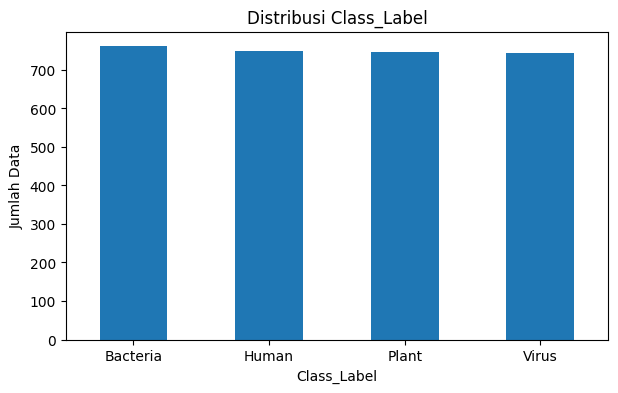

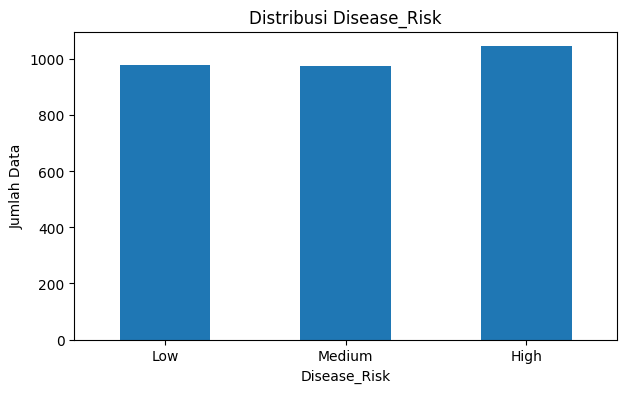

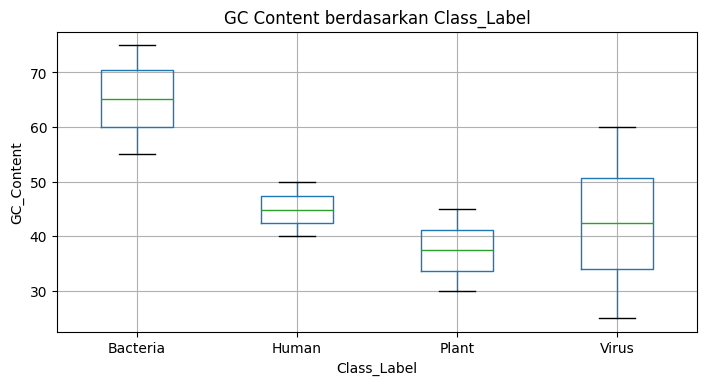

In [5]:
# Visualisasi sederhana menggunakan pandas + matplotlib.
# Dibuat tanpa seaborn agar kompatibel di Kaggle/Jupyter/Colab.

fig, ax = plt.subplots(figsize=(7, 4))
df['Class_Label'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Distribusi Class_Label')
ax.set_xlabel('Class_Label')
ax.set_ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
df['Disease_Risk'].value_counts().reindex(['Low', 'Medium', 'High']).plot(kind='bar', ax=ax)
ax.set_title('Distribusi Disease_Risk')
ax.set_xlabel('Disease_Risk')
ax.set_ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='GC_Content', by='Class_Label', ax=ax)
ax.set_title('GC Content berdasarkan Class_Label')
ax.set_xlabel('Class_Label')
ax.set_ylabel('GC_Content')
plt.suptitle('')
plt.show()

## 5. Fungsi Evaluasi Model

Beberapa model dibandingkan, lalu model terbaik dipilih berdasarkan **weighted F1-score**.

In [6]:
def evaluate_models(X_train, X_test, y_train, y_test, candidates):
    rows = []
    best_name = None
    best_model = None
    best_f1 = -1

    for name, candidate_model in candidates.items():
        model = clone(candidate_model)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, pred, average='weighted', zero_division=0
        )
        rows.append({
            'model': name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
        })
        if f1 > best_f1:
            best_f1 = f1
            best_name = name
            best_model = model

    return pd.DataFrame(rows).sort_values('f1_score', ascending=False), best_name, best_model

candidates = {
    'RandomForest': RandomForestClassifier(n_estimators=220, random_state=RANDOM_STATE, class_weight='balanced_subsample', n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=220, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
}

## 6. Training Model Klasifikasi Kelas DNA

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)
class_results, best_class_name, best_class_model = evaluate_models(X_train, X_test, y_train, y_test, candidates)
class_results

,model,accuracy,precision,recall,f1_score
1,ExtraTrees,0.706667,0.699563,0.706667,0.685230
0,RandomForest,0.705000,0.705721,0.705000,0.683361
2,LogisticRegression,0.670000,0.694441,0.670000,0.605555


In [8]:
class_pred = best_class_model.predict(X_test)
print('Best class model:', best_class_name)
print(classification_report(y_test, class_pred, zero_division=0))

Best class model: ExtraTrees
              precision    recall  f1-score   support

    Bacteria       0.86      0.95      0.90       152
       Human       0.66      0.89      0.76       150
       Plant       0.64      0.64      0.64       149
       Virus       0.64      0.33      0.44       149

    accuracy                           0.71       600
   macro avg       0.70      0.71      0.68       600
weighted avg       0.70      0.71      0.69       600



## 7. Training Model Tingkat Keparahan/Risiko

In [9]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=RANDOM_STATE, stratify=y_risk
)
risk_results, best_risk_name, best_risk_model = evaluate_models(Xr_train, Xr_test, yr_train, yr_test, candidates)
risk_results

,model,accuracy,precision,recall,f1_score
0,RandomForest,0.430000,0.424135,0.430000,0.423805
2,LogisticRegression,0.451667,0.440660,0.451667,0.414316
1,ExtraTrees,0.416667,0.409545,0.416667,0.409513


In [10]:
risk_pred = best_risk_model.predict(Xr_test)
print('Best risk model:', best_risk_name)
print(classification_report(yr_test, risk_pred, zero_division=0))

Best risk model: RandomForest
              precision    recall  f1-score   support

        High       0.48      0.59      0.53       209
         Low       0.42      0.35      0.38       196
      Medium       0.37      0.34      0.36       195

    accuracy                           0.43       600
   macro avg       0.42      0.43      0.42       600
weighted avg       0.42      0.43      0.42       600



## 8. Model Tambahan: Deteksi High Risk

Selain prediksi Low/Medium/High, dibuat model biner untuk mendeteksi apakah sequence termasuk kategori **High Risk** atau bukan.

In [11]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X, y_high_risk, test_size=0.2, random_state=RANDOM_STATE, stratify=y_high_risk
)
high_results, best_high_name, best_high_model = evaluate_models(Xh_train, Xh_test, yh_train, yh_test, candidates)
high_results

,model,accuracy,precision,recall,f1_score
2,LogisticRegression,0.623333,0.722673,0.623333,0.627307
1,ExtraTrees,0.625000,0.604735,0.625000,0.610424
0,RandomForest,0.613333,0.585352,0.613333,0.592131


In [12]:
high_pred = best_high_model.predict(Xh_test)
print('Best high risk model:', best_high_name)
print(classification_report(yh_test, high_pred, target_names=['Not High', 'High'], zero_division=0))

if hasattr(best_high_model, 'predict_proba'):
    high_auc = roc_auc_score(yh_test, best_high_model.predict_proba(Xh_test)[:, 1])
    print('AUC High Risk:', round(high_auc, 4))
else:
    high_auc = None

Best high risk model: LogisticRegression
              precision    recall  f1-score   support

    Not High       0.85      0.51      0.64       391
        High       0.48      0.84      0.61       209

    accuracy                           0.62       600
   macro avg       0.67      0.67      0.62       600
weighted avg       0.72      0.62      0.63       600

AUC High Risk: 0.6834


## 9. Simpan Model

Model disimpan dalam folder `models/` agar bisa langsung dipanggil oleh `app.py`.

In [13]:
metadata = {
    'dataset_rows_used': int(len(df)),
    'feature_columns': FEATURE_COLUMNS,
    'excluded_leakage_columns': LEAKAGE_COLUMNS,
    'class_labels': sorted(y_class.unique().tolist()),
    'risk_labels': sorted(y_risk.unique().tolist()),
    'best_class_model': best_class_name,
    'best_risk_model': best_risk_name,
    'best_high_risk_model': best_high_name,
    'important_note': 'Disease_Risk adalah label prediktif dari dataset, bukan diagnosis medis final.',
}

joblib.dump(best_class_model, MODEL_DIR / 'organism_classifier.joblib')
joblib.dump(best_risk_model, MODEL_DIR / 'severity_classifier.joblib')
joblib.dump(best_high_model, MODEL_DIR / 'high_risk_classifier.joblib')
joblib.dump(metadata, MODEL_DIR / 'metadata.joblib')

metrics = {
    'class_model_results': class_results.to_dict(orient='records'),
    'risk_model_results': risk_results.to_dict(orient='records'),
    'high_risk_model_results': high_results.to_dict(orient='records'),
    'metadata': metadata,
}
Path('models/metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print('Model berhasil disimpan ke folder models/')

Model berhasil disimpan ke folder models/


## 10. Uji Prediksi dari Sequence Baru

Contoh berikut menunjukkan alur yang sama dengan aplikasi Streamlit: sequence dimasukkan, fitur dihitung, lalu model melakukan prediksi.

In [14]:
example_sequence = df['Sequence'].iloc[0]
X_new = build_feature_frame([example_sequence], mutation_flags=[1])

print('Sequence:', example_sequence[:60] + '...')
print('Prediksi kelas:', best_class_model.predict(X_new)[0])
print('Prediksi risiko:', best_risk_model.predict(X_new)[0])
print('Prediksi high risk:', best_high_model.predict(X_new)[0])
X_new

Sequence: CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCGCAGACAGACTTTAA...
Prediksi kelas: Human
Prediksi risiko: Low
Prediksi high risk: 1


,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,GC_to_AT_Ratio,Sequence_Entropy
0,50.0,50.0,100.0,22.0,28.0,19.0,31.0,0.510204,1,1.0,1.973815


## 11. Integrasi Streamlit

Setelah model tersimpan, aplikasi dapat dijalankan dengan:

```bash
streamlit run app.py
```

Untuk deploy online, upload project ini ke GitHub lalu hubungkan ke Streamlit Community Cloud dengan main file `app.py`.